# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does

1. Extracts **fixed 5s windows** and associates the corresponding labels
2. Embeds all windows with **Perch V2**
3. Evaluates **zero-shot** performance using Perch V2's built-in logits
4. Trains a **linear classifier** on top of the embeddings
5. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-05-04 13:03:01.089706: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 13:03:03.251239: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 13:03:09.068787: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

In [4]:
#@title Configuration { vertical-output: true }

#@markdown Folder containing all .wav files
wav_folder = '/data2/mromaniuc/cet-det/datasets/ECOSS/annotated_sounds'  #@param {type:'string'}

#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/ECOSS/annotated_sounds'

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [5]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1777892601.016692   26149 gpu_device.cc:2020] Created device /device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9
I0000 00:00:1777892601.423880   26149 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


In [6]:
#@title ECOSS Annotated — Dataset Inventory
import soundfile as sf
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

wav_folder = Path(wav_folder)  # convert string from config cell

class_dirs = sorted([
    d for d in wav_folder.iterdir()
    if d.is_dir() and d.name != 'spectrograms'
])
print(f'Found {len(class_dirs)} classes: {[d.name for d in class_dirs]}')

# ── Collect file info ─────────────────────────────────────────────────────────
records = []
skipped = []

for class_dir in class_dirs:
    label = class_dir.name
    files = sorted(
        list(class_dir.glob('*.wav'))  +
        list(class_dir.glob('*.WAV'))  +
        list(class_dir.glob('*.flac')) +
        list(class_dir.glob('*.FLAC'))
    )
    for f in tqdm(files, desc=label):
        try:
            info = sf.info(str(f))
            records.append({
                'label':       label,
                'file':        f.name,
                'duration_s':  info.duration,
                'sample_rate': info.samplerate,
                'channels':    info.channels,
                'format':      info.format,
            })
        except Exception as e:
            skipped.append((f.name, str(e)))

df = pd.DataFrame(records)

# ── Global summary ────────────────────────────────────────────────────────────
print(f'\n=== Global Summary ({len(df)} files) ===')
print(f'Min duration:    {df.duration_s.min():.3f}s')
print(f'Max duration:    {df.duration_s.max():.3f}s')
print(f'Mean duration:   {df.duration_s.mean():.3f}s')
print(f'Median duration: {df.duration_s.median():.3f}s')
print(f'Total audio:     {df.duration_s.sum()/3600:.2f} hours')

# ── Per-class summary ─────────────────────────────────────────────────────────
print(f'\n=== Per-class Summary ===')
summary = df.groupby('label').agg(
    n_files      =('file',        'count'),
    duration_mean=('duration_s',  'mean'),
    duration_min =('duration_s',  'min'),
    duration_max =('duration_s',  'max'),
    total_hours  =('duration_s',  lambda x: x.sum() / 3600),
).round(3)
print(summary.to_string())

# ── Sample rates per class ────────────────────────────────────────────────────
print(f'\n=== Sample Rates per Class ===')
sr_summary = df.groupby(['label', 'sample_rate']).size().reset_index(name='n_files')
print(sr_summary.to_string(index=False))

# ── Overall sample rate distribution ─────────────────────────────────────────
print(f'\n=== Overall Sample Rate Distribution ===')
print(df['sample_rate'].value_counts().to_string())

if skipped:
    print(f'\nSkipped {len(skipped)} files:')
    for f, e in skipped[:10]:
        print(f'  {f}: {e}')

Found 5 classes: ['Chains', 'Hammer', 'Odontocetes_Delphinids', 'Odontocetes_SpermWhale', 'WaveEnergyConvertor']


WaveEnergyConvertor: 100%|██████████| 175/175 [00:00<00:00, 294.51it/s]


=== Global Summary (2783 files) ===
Min duration:    0.018s
Max duration:    599.987s
Mean duration:   2.504s
Median duration: 0.700s
Total audio:     1.94 hours

=== Per-class Summary ===
                        n_files  duration_mean  duration_min  duration_max  total_hours
label                                                                                  
Chains                     1111          1.608         0.052        42.000        0.496
Hammer                     1011          0.700         0.700         0.700        0.197
Odontocetes_Delphinids      401          7.397         0.122       599.987        0.824
Odontocetes_SpermWhale       85          0.582         0.018         2.183        0.014
WaveEnergyConvertor         175          8.340         0.262       594.999        0.405

=== Sample Rates per Class ===
                 label  sample_rate  n_files
                Chains        39062        4
                Chains        48000        1
                Chains     

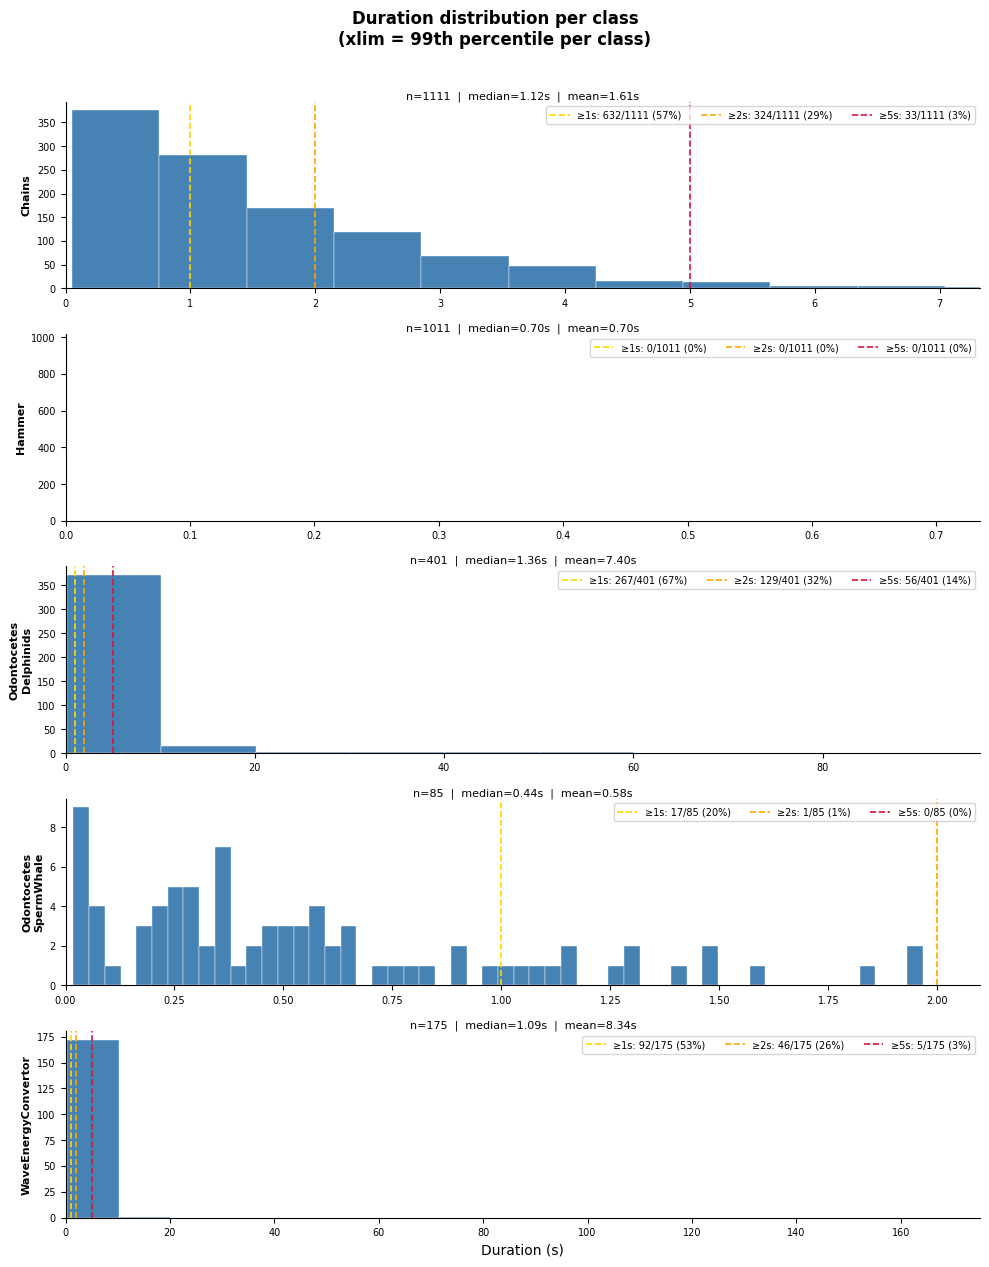

In [7]:
#@title Duration distribution per class
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(class_dirs), 1,
                         figsize=(10, len(class_dirs) * 2.5),
                         sharex=False)

thresholds = [1, 2, 5]  # lines to draw

for ax, class_dir in zip(axes, class_dirs):
    lbl  = class_dir.name
    data = df[df['label'] == lbl]['duration_s'].values

    ax.hist(data, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)

    for t, c in zip(thresholds, ['gold', 'orange', 'crimson']):
        kept = (data >= t).sum()
        ax.axvline(t, color=c, linestyle='--', linewidth=1.2,
                   label=f'≥{t}s: {kept}/{len(data)} ({kept/len(data)*100:.0f}%)')

    ax.set_xlim(0, np.percentile(data, 99) * 1.05)  # ignore extreme outliers for readability
    ax.set_ylabel(lbl.replace('_', '\n'), fontsize=8, fontweight='bold')
    ax.set_title(f'n={len(data)}  |  median={np.median(data):.2f}s  |  mean={np.mean(data):.2f}s',
                 fontsize=8, pad=2)
    ax.legend(fontsize=7, ncol=3, loc='upper right')
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel('Duration (s)')
fig.suptitle('Duration distribution per class\n(xlim = 99th percentile per class)',
             fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


We will only keep files >5s

In [8]:
# ── Window → Spectrogram only (no wav written) ────────────────────────────────
import soundfile as sf
import librosa
import soxr
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

OUTPUT_DIR  = Path(wav_folder)
SPEC_DIR    = OUTPUT_DIR / 'spectrograms'
TARGET_SR   = 32000
WINDOW_S    = 5.0
TARGET_LEN  = int(WINDOW_S * TARGET_SR)
DROP_LABELS = {}

N_FFT      = 2048
HOP_LENGTH = 160
N_MELS     = 128
FMIN       = 60
FMAX       = 16000

class_dirs = sorted([
    d for d in OUTPUT_DIR.iterdir()
    if d.is_dir() and d.name not in DROP_LABELS and d.name != 'spectrograms'
])
print(f'Classes: {[d.name for d in class_dirs]}')

records       = []
skipped       = []
total_windows = 0

for class_dir in class_dirs:
    label        = class_dir.name
    spec_out_dir = SPEC_DIR / label
    spec_out_dir.mkdir(parents=True, exist_ok=True)

    files = sorted(
        list(class_dir.glob('*.wav'))  +
        list(class_dir.glob('*.WAV'))  +
        list(class_dir.glob('*.flac')) +
        list(class_dir.glob('*.FLAC'))
    )

    for f in tqdm(files, desc=label):
        try:
            audio, native_sr = librosa.load(str(f), sr=None, mono=True)

            if native_sr != TARGET_SR:
                audio = soxr.resample(audio, native_sr, TARGET_SR)

            # ── skip files shorter than 5s after resampling ───────────────
            duration_s = len(audio) / TARGET_SR
            if duration_s < 5.0:
                skipped.append((f.name, f'too short ({duration_s:.2f}s)'))
                continue

            n_windows = int(len(audio) // TARGET_LEN)

            for i in range(n_windows):
                seg      = audio[i * TARGET_LEN : (i + 1) * TARGET_LEN].astype(np.float32)
                png_path = spec_out_dir / f'{f.stem}_seg{i:03d}.png'

                records.append({
                    'label':     label,
                    'file':      f'{f.stem}_seg{i:03d}',
                    'source':    f.name,
                    'src_path':  str(f),
                    'segment':   i,
                    'native_sr': native_sr,
                    'spec_path': str(png_path),
                })

                if png_path.exists():
                    continue

                S    = librosa.feature.melspectrogram(
                    y=seg, sr=TARGET_SR,
                    n_fft=N_FFT, hop_length=HOP_LENGTH,
                    n_mels=N_MELS, fmin=FMIN, fmax=FMAX
                )
                S_db = librosa.power_to_db(S, ref=np.max)

                fig, ax = plt.subplots(figsize=(4, 3))
                img = librosa.display.specshow(
                    S_db, sr=TARGET_SR, hop_length=HOP_LENGTH,
                    fmin=FMIN, fmax=FMAX,
                    x_axis='time', y_axis='mel',
                    ax=ax, cmap='viridis'
                )
                ax.set_title(f'{f.name}  seg{i}  |  native {native_sr}Hz',
                            fontsize=6, pad=2)
                ax.set_xlabel('Time (s)', fontsize=6)
                ax.set_ylabel('Hz', fontsize=6)
                ax.tick_params(labelsize=5)
                fig.colorbar(img, ax=ax, format='%+2.0f dB', pad=0.02)
                fig.tight_layout(pad=0.5)
                fig.savefig(str(png_path), dpi=100, bbox_inches='tight')
                plt.close(fig)
                total_windows += 1

        except Exception as e:
            skipped.append((f.name, str(e)))
            plt.close('all')
            print(f'  SKIP {f.name}: {e}')

# ── Save manifest ─────────────────────────────────────────────────────────────
df_seg = pd.DataFrame(records)
df_seg.to_csv(OUTPUT_DIR / 'manifest.csv', index=False)

print(f'\n=== Segmentation Summary ===')
print(df_seg.groupby('label')['file'].count().rename('n_segments').to_string())
print(f'\nTotal windows : {len(df_seg)}')
print(f'New spectrograms saved: {total_windows}')
print(f'Skipped: {len(skipped)}')
for f, reason in skipped:
    print(f'  {f}: {reason}')

Classes: ['Chains', 'Hammer', 'Odontocetes_Delphinids', 'Odontocetes_SpermWhale', 'WaveEnergyConvertor']


Chains:   0%|          | 0/1111 [00:00<?, ?it/s]

WaveEnergyConvertor: 100%|██████████| 175/175 [01:15<00:00,  2.31it/s] 


=== Segmentation Summary ===
label
Chains                     45
Odontocetes_Delphinids    466
WaveEnergyConvertor       241

Total windows : 752
New spectrograms saved: 752
Skipped: 2689
  Anthropogenic_Chains_27.4.c_192000_16_1_10.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_15.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_21.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_22.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_24.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_25.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_29.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_30.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_32.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_34.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_37.flac: too short (1.00s)
  Anthropogenic_Chains_27.4.c_192000_16_1_38.flac: t

In [11]:
# ── Load manifest ─────────────────────────────────────────────────────────────
df_seg = pd.read_csv(OUTPUT_DIR / 'manifest.csv')
print(f'Loaded {len(df_seg)} segments')
print(df_seg['label'].value_counts().to_string())

TARGET_SAMPLES = int(WINDOW_S * sr)  # sr from Perch model

# ── Extract embeddings ────────────────────────────────────────────────────────
embeddings_list, logits_list, labels_list, failed_idx = [], [], [], []

for i, row in tqdm(df_seg.iterrows(), total=len(df_seg)):
    try:
        audio, native_sr = librosa.load(row['src_path'], sr=None, mono=True)
        if native_sr != sr:
            audio = soxr.resample(audio, native_sr, sr)

        # slice the exact 5s window
        start = row['segment'] * TARGET_SAMPLES
        audio = audio[start : start + TARGET_SAMPLES].astype(np.float32)

        if len(audio) < TARGET_SAMPLES:
            audio = np.pad(audio, (0, TARGET_SAMPLES - len(audio)))

        out = embedding_model.embed(audio)
        embeddings_list.append(out.embeddings[0].mean(axis=0))
        logits_list.append(out.logits['label'][0])
        labels_list.append(row['label'])

    except Exception as e:
        failed_idx.append(i)
        print(f'  FAILED [{i}] {row["file"]} — {repr(e)}')


X = np.stack(embeddings_list)
Z = np.stack(logits_list)
y = np.array(labels_list)

print(f'\nDone. {len(X)} embedded, {len(failed_idx)} failed.')
print(f'Embedding shape : {X.shape}')
print(f'Logits shape    : {Z.shape}')
print(f'\nClass distribution:')
print(pd.Series(y).value_counts().to_string())

# ── NaN check ─────────────────────────────────────────────────────────────────
nan_X   = np.isnan(X).any(axis=1)
nan_Z   = np.isnan(Z).any(axis=1)
nan_any = nan_X | nan_Z
print(f'\nNaN rows — X: {nan_X.sum()}  Z: {nan_Z.sum()}')
if nan_any.sum() > 0 and nan_any.sum() / len(X) < 0.05:
    valid = ~nan_any
    X, Z, y = X[valid], Z[valid], y[valid]
    df_seg  = df_seg[valid].reset_index(drop=True)
    print(f'Dropped {nan_any.sum()} NaN rows.')

# ── Save ──────────────────────────────────────────────────────────────────────
emb_dir = Path(save_dir) / 'embeddings'
emb_dir.mkdir(exist_ok=True)

np.save(emb_dir / 'X_embeddings.npy', X)
np.save(emb_dir / 'Z_logits.npy',     Z)
np.save(emb_dir / 'y_labels.npy',     y)
df_seg.to_csv(emb_dir / 'metadata.csv', index=False)

print(f'\nSaved to {emb_dir}')
print(f'  X: {X.shape}  Z: {Z.shape}  y: {y.shape}')

Loaded 752 segments
label
Odontocetes_Delphinids    466
WaveEnergyConvertor       241
Chains                     45


100%|██████████| 752/752 [09:58<00:00,  1.26it/s]


Done. 752 embedded, 0 failed.
Embedding shape : (752, 1536)
Logits shape    : (752, 14795)

Class distribution:
Odontocetes_Delphinids    466
WaveEnergyConvertor       241
Chains                     45

NaN rows — X: 0  Z: 0

Saved to /data2/mromaniuc/cet-det/models/perch_v2/ECOSS/annotated_sounds/embeddings
  X: (752, 1536)  Z: (752, 14795)  y: (752,)


# retrieving the data and performing zero-shot and fully-supervised classifications

In [12]:
X_clean =  np.load(f'{save_dir}/embeddings/X_embeddings.npy')  
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   
Z_clean = np.load(f'{save_dir}/embeddings/Z_logits.npy')   

metadata_clean = pd.read_csv(f'{save_dir}/embeddings/metadata.csv')

print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'Class distribution:')
print(pd.Series(y_clean).value_counts())

Clean shapes — X: (752, 1536), Z: (752, 14795), y: (752,)
Class distribution:
Odontocetes_Delphinids    466
WaveEnergyConvertor       241
Chains                     45
Name: count, dtype: int64


In [ ]:
# Search for dolphin/whale/cetacean related classes
for name in perch_class_names:
    if any(term in name.lower() for term in ['chain', 'wave', 'energy', 'dolphin', 'orca', 'whale', 'balaena', 'balaenoptera', 'Stenella_coeruleoalba', 'Grampus_griseus', 'Physeter_macrocephalus', 'Globicephala_melas', 'Balaenoptera_physalus', 'tursiops', 'whale', 'cetac', 'porpoise', 'whistle', 'cetacean', 'delphinus', 'delphis', 'cetacea']):
        print(name)

Balaena mysticetus
Balaenoptera physalus
Budorcas taxicolor
Didelphis virginiana
Eubalaena australis
Eubalaena glacialis
Ingerophrynus biporcatus
Ingerophrynus quadriporcatus
Microwave_oven
Myzomela adolphinae
Orcinus orca
Phylloscopus whistleri
Sternula balaenarum
Tursiops truncatus
Waves_and_surf


In [16]:
#@title Zero-shot species analysis — ECOSS Enhanced4AI

class_names_list = list(embedding_model.class_list['labels'].classes)

# Best Perch class match for each ECOSS label
expected_mapping = {
    'Odontocetes_Delphinids': 'Tursiops truncatus',
    'WaveEnergyConvertor':   'Water',
    'Chains':   'Water'
}


# ── Build masks + mean logits ─────────────────────────────────────────────────
masks       = {s: (y_clean == s) for s in expected_mapping}
mean_logits = {s: Z_clean[masks[s]].mean(axis=0)
               for s in expected_mapping if masks[s].sum() > 0}

# ── Top 20 per class ──────────────────────────────────────────────────────────
for species, logits in mean_logits.items():
    top_idx      = np.argsort(logits)[::-1][:20]
    expected     = expected_mapping[species]
    try:
        expected_idx  = class_names_list.index(expected)
        expected_rank = np.where(np.argsort(logits)[::-1] == expected_idx)[0][0] + 1
        expected_str  = f'"{expected}" — rank #{expected_rank}, logit={logits[expected_idx]:.3f}'
    except ValueError:
        expected_str  = f'"{expected}" — NOT IN PERCH CLASS LIST'

    print(f'TOP 20 PERCH CLASSES FOR {species.upper()} (n={masks[species].sum()}):')
    print(f'  Expected: {expected_str}')
    print('-' * 60)
    for idx in top_idx:
        marker = '  <-- expected' if class_names_list[idx] == expected else ''
        print(f'  {logits[idx]:6.3f}  {class_names_list[idx]}{marker}')
    print()

# ── Candidate comparison tables ───────────────────────────────────────────────
def safe_idx(name):
    try:
        return class_names_list.index(name)
    except ValueError:
        print(f'  WARNING: "{name}" not in Perch class list')
        return None

def print_candidate_table(title, candidate_names):
    candidates = {n: safe_idx(n) for n in candidate_names}
    candidates = {n: i for n, i in candidates.items() if i is not None}
    if not candidates:
        return
    col_w = 20
    print(title)
    print('-' * (37 + col_w * len(mean_logits)))
    header = f'  {"Perch class":35s}'
    for species in mean_logits:
        header += f'  {species[:col_w-2]:>{col_w-2}s}'
    print(header)
    print('-' * (37 + col_w * len(mean_logits)))
    for name, idx in candidates.items():
        row = f'  {name:35s}'
        for logits in mean_logits.values():
            rank = np.where(np.argsort(logits)[::-1] == idx)[0][0] + 1
            row += f'  {logits[idx]:6.3f} (#{rank:<4d})'
        print(row)
    print()

print_candidate_table('ODONTOCETE CANDIDATES:', [
    'Tursiops truncatus',
    'Orcinus orca',
    'Physeter macrocephalus',
])

print_candidate_table('ANTHROPOGENIC / BACKGROUND CANDIDATES:', [
    'Boat_and_Water_vehicle',
    'Water',
    'Ocean',
])

TOP 20 PERCH CLASSES FOR ODONTOCETES_DELPHINIDS (n=466):
  Expected: "Tursiops truncatus" — rank #11060, logit=-2.101
------------------------------------------------------------
   6.631  Rain
   6.577  Domestic_sounds_and_home_sounds
   6.426  Water
   5.787  Fire
   5.717  Animal
   5.242  Crackle
   5.084  Wild_animals
   4.919  Vehicle
   4.715  Wind
   4.708  Frying_(food)
   4.671  Strix aluco
   4.573  Engine
   4.564  Strix varia
   4.559  Erithacus rubecula
   4.524  Liquid
   4.501  Bathtub_(filling_or_washing)
   4.453  Mechanisms
   4.441  Fringilla coelebs
   4.435  Phylloscopus collybita
   4.430  Parus major

TOP 20 PERCH CLASSES FOR WAVEENERGYCONVERTOR (n=241):
  Expected: "Water" — rank #114, logit=3.409
------------------------------------------------------------
   5.831  Domestic_sounds_and_home_sounds
   5.571  Turdus merula
   5.456  Cyanocitta cristata
   5.365  Strix aluco
   5.318  Tyto alba
   5.297  Asio otus
   5.279  Picus viridis
   5.215  Numenius phaeop

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ── Load embeddings if not already in memory ──────────────────────────────────
df_seg = pd.read_csv(save_dir + '/embeddings/metadata.csv')

assert len(df_seg) == len(X_clean), \
    f'mismatch: {len(df_seg)} segments vs {len(X_clean)} embeddings'

# ── Encode labels ─────────────────────────────────────────────────────────────
le = LabelEncoder()
y_enc       = le.fit_transform(y_clean)
class_names = list(le.classes_)
print('Classes:', class_names)

# ── Split on embeddings directly ──────────────────────────────────────────────
X_train, X_test, y_train, y_test, Z_train, Z_test, idx_train, idx_test = \
    train_test_split(X_clean, y_enc, Z_clean, np.arange(len(X_clean)),
                     test_size=test_size, random_state=random_seed, stratify=y_enc)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')
print(f'Test fraction: {len(X_test) / len(X_clean):.2%}')

print('\nTest set class distribution:')
print(pd.Series(le.inverse_transform(y_test)).value_counts().to_string())

Classes: ['Chains', 'Odontocetes_Delphinids', 'WaveEnergyConvertor']
Train: 526  |  Test: 226
Test fraction: 30.05%

Test set class distribution:
Odontocetes_Delphinids    140
WaveEnergyConvertor        72
Chains                     14


In [34]:
#@title Train classifiers + track metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import time

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=random_seed, class_weight='balanced', multi_class='multinomial'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, random_state=random_seed, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True
    ),
}

results = {}
n_classes = len(class_names)

for name, clf in classifiers.items():
    print(f'\nTraining {name}...')
    t0 = time.time()

    clf.fit(X_train_sc, y_train)
    y_pred   = clf.predict(X_test_sc)
    y_proba  = clf.predict_proba(X_test_sc)
    elapsed  = time.time() - t0

    f1_macro     = f1_score(y_test, y_pred, average='macro')
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=range(n_classes))
    train_acc    = clf.score(X_train_sc, y_train)
    test_acc     = clf.score(X_test_sc,  y_test)

    try:
        auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    results[name] = {
        'clf': clf, 'y_pred': y_pred, 'y_proba': y_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_acc, 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed,
    }

    print(f'  Time: {elapsed:.1f}s | Train: {train_acc:.4f} | Test: {test_acc:.4f} | '
          f'Macro F1: {f1_macro:.4f} | ROC AUC (OVR): {auc_ovr:.4f}')
    print(classification_report(y_test, y_pred, target_names=class_names))

    print('  Per-class F1:')
    for cn, f1 in zip(class_names, f1_per_class):
        print(f'    {cn:40s} {f1:.4f}')

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '=' * 100)
print(f'SUMMARY — {n_classes}-CLASS EVALUATION ')
print('=' * 100)
print(f'{"Classifier":<20} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} {"Test":>8} {"Gap":>6} {"Time":>6}')
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<20} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} {gap:>6.4f} {res["time_s"]:>6.1f}s')

print('\n' + '=' * 100)
print('PER-CLASS F1 COMPARISON')
print('=' * 100)
header = f'{"Classifier":<20}'
for cn in class_names:
    header += f' {cn:>40s}'
print(header)
print('-' * 100)
for name, res in sorted(results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    row = f'{name:<20}'
    for f1 in res['f1_per_class']:
        row += f' {f1:>40.4f}'
    print(row)


Training Logistic Regression...
  Time: 0.0s | Train: 1.0000 | Test: 0.9690 | Macro F1: 0.8908 | ROC AUC (OVR): 0.9912
                        precision    recall  f1-score   support

                Chains       0.82      0.64      0.72        14
Odontocetes_Delphinids       1.00      1.00      1.00       140
   WaveEnergyConvertor       0.93      0.97      0.95        72

              accuracy                           0.97       226
             macro avg       0.92      0.87      0.89       226
          weighted avg       0.97      0.97      0.97       226

  Per-class F1:
    Chains                                   0.7200
    Odontocetes_Delphinids                   1.0000
    WaveEnergyConvertor                      0.9524

Training Decision Tree...
  Time: 0.3s | Train: 1.0000 | Test: 0.9425 | Macro F1: 0.8245 | ROC AUC (OVR): 0.9510
                        precision    recall  f1-score   support

                Chains       0.86      0.43      0.57        14
Odontocetes_De

In [35]:
#@title PyTorch MLP with Dropout (ECOSS multiclass)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score
import copy
import time

n_classes = len(class_names)
print(f'Classes: {class_names}')
print(f'Train: {len(y_train)}  |  Test: {len(y_test)}')
print(f'Train dist: {dict(zip(class_names, np.bincount(y_train, minlength=n_classes)))}')
print(f'Test dist:  {dict(zip(class_names, np.bincount(y_test,  minlength=n_classes)))}')

# ── Architecture definitions ──────────────────────────────────────────────────
torch_mlp_configs = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,), 'dropout': 0.4, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
    'PyTorch MLP (256,128) drop=0.5': {
        'hidden': (256, 128), 'dropout': 0.5, 'lr': 1e-4,
        'weight_decay': 1e-3, 'epochs': 300, 'patience': 30, 'batch_size': 256,
    },
}

def build_mlp(input_dim, hidden_sizes, dropout, n_classes):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Class weights for loss (inverse frequency, normalized)
class_counts = np.bincount(y_train, minlength=n_classes)
class_weights = torch.tensor(
    [class_counts.sum() / (n_classes * c) if c > 0 else 0.0 for c in class_counts],
    dtype=torch.float32
).to(device)
print(f'Class weights: {dict(zip(class_names, class_weights.cpu().numpy().round(3)))}')

mlp_results = {}

for name, cfg in torch_mlp_configs.items():
    print(f'\nTraining {name}...')

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_sc, y_train, test_size=0.15,
        random_state=random_seed, stratify=y_train
    )

    X_tr_t  = torch.tensor(X_tr,  dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.long).to(device)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.long).to(device)
    X_te_t  = torch.tensor(X_test_sc, dtype=torch.float32).to(device)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=cfg['batch_size'], shuffle=True)

    input_dim = X_train_sc.shape[1]
    model     = build_mlp(input_dim, cfg['hidden'], cfg['dropout'], n_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_state       = None
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    best_epoch       = 0
    early_stopped    = False

    t0 = time.time()

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            tr_logits  = model(X_tr_t)
            val_logits = model(X_val_t)
            tr_loss  = criterion(tr_logits,  y_tr_t).item()
            val_loss = criterion(val_logits, y_val_t).item()
            tr_acc   = (tr_logits.argmax(1)  == y_tr_t).float().mean().item()
            val_acc  = (val_logits.argmax(1) == y_val_t).float().mean().item()

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            best_epoch       = epoch
            best_state       = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
        if patience_counter >= cfg['patience']:
            early_stopped = True
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_t)
        test_proba  = torch.softmax(test_logits, dim=1).cpu().numpy()
        test_pred   = test_logits.argmax(1).cpu().numpy()

    elapsed = time.time() - t0
    n_iter  = len(train_losses)

    f1_macro     = f1_score(y_test, test_pred, average='macro')
    f1_per_class = f1_score(y_test, test_pred, average=None, labels=range(n_classes))
    test_acc     = accuracy_score(y_test, test_pred)

    try:
        auc_ovr = roc_auc_score(y_test, test_proba, multi_class='ovr', average='weighted')
    except ValueError:
        auc_ovr = float('nan')

    mlp_results[name] = {
        'y_pred': test_pred, 'y_proba': test_proba,
        'f1_macro': f1_macro, 'f1_per_class': f1_per_class,
        'train_acc': train_accs[-1], 'test_acc': test_acc,
        'auc_ovr': auc_ovr, 'time_s': elapsed, 'n_iter': n_iter,
        'train_losses': train_losses, 'val_losses': val_losses,
        'train_accs': train_accs, 'val_accs': val_accs,
        'best_epoch': best_epoch, 'early_stopped': early_stopped
    }

    print(f'  Epochs: {n_iter} | Best: {best_epoch} | Early stop: {early_stopped}')
    print(f'  Time: {elapsed:.1f}s | Train Acc: {train_accs[-1]:.4f} | '
          f'Test Acc: {test_acc:.4f} | Macro F1: {f1_macro:.4f} | AUC OVR: {auc_ovr:.4f}')
    print(classification_report(y_test, test_pred, target_names=class_names, zero_division=0))

    print('  Per-class F1:')
    for i, cn in enumerate(class_names):
        print(f'    {cn:30s} {f1_per_class[i]:.4f}')

# ── Summary ───────────────────────────────────────────────────────────────────
print('\n' + '=' * 100)
print(f'PyTorch MLP SUMMARY ({n_classes}-class ECOSS)')
print('=' * 100)
print(f'{"Model":<40} {"Macro F1":>8} {"AUC OVR":>8} {"Train":>8} '
      f'{"Test":>8} {"Gap":>6} {"Epochs":>7} {"Time":>8}')
print('-' * 100)
for name, res in sorted(mlp_results.items(), key=lambda x: x[1]['f1_macro'], reverse=True):
    gap = abs(res['train_acc'] - res['test_acc'])
    print(f'{name:<40} {res["f1_macro"]:>8.4f} {res["auc_ovr"]:>8.4f} '
          f'{res["train_acc"]:>8.4f} {res["test_acc"]:>8.4f} '
          f'{gap:>6.4f} {res["n_iter"]:>7} {res["time_s"]:>8.1f}')

if 'results' in dir():
    results.update(mlp_results)
    print('\n✓ PyTorch MLP results merged into overall results dict.')

Classes: ['Chains', 'Odontocetes_Delphinids', 'WaveEnergyConvertor']
Train: 526  |  Test: 226
Train dist: {'Chains': 31, 'Odontocetes_Delphinids': 326, 'WaveEnergyConvertor': 169}
Test dist:  {'Chains': 14, 'Odontocetes_Delphinids': 140, 'WaveEnergyConvertor': 72}
Using device: cuda
Class weights: {'Chains': 5.656, 'Odontocetes_Delphinids': 0.538, 'WaveEnergyConvertor': 1.037}

Training PyTorch MLP (128) drop=0.4...
  Epochs: 57 | Best: 27 | Early stop: True
  Time: 0.4s | Train Acc: 0.9978 | Test Acc: 0.9513 | Macro F1: 0.8698 | AUC OVR: 0.9954
                        precision    recall  f1-score   support

                Chains       0.89      0.57      0.70        14
Odontocetes_Delphinids       1.00      0.97      0.99       140
   WaveEnergyConvertor       0.88      0.99      0.93        72

              accuracy                           0.95       226
             macro avg       0.92      0.84      0.87       226
          weighted avg       0.95      0.95      0.95       22

In [36]:
import matplotlib.pyplot as plt
import numpy as np


color_palette = ['steelblue', 'darkorange', 'seagreen']
colors = {name: color_palette[i % len(color_palette)] for i, name in enumerate(mlp_results)}

n_models = len(mlp_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing works

fig.suptitle('MLP Training Dynamics on 3 classes — Perch V2 Embeddings',
             fontsize=16, fontweight='bold', y=0.98)

for idx, (name, res) in enumerate(mlp_results.items()):
    color = colors[name]
    epochs = np.arange(1, res['n_iter'] + 1)

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, res['train_losses'], label='Train Loss',
                 color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_loss.plot(epochs, res['val_losses'], label='Val Loss',
                 color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_loss.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6,
                    label=f'Best Epoch ({res["best_epoch"]})')
    ax_loss.set_title(f'{name}\n— Log Loss', fontsize=11, pad=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Log Loss')
    ax_loss.legend(fontsize=8)
    ax_loss.grid(alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, res['train_accs'], label='Train Acc',
                color=color, linewidth=2, marker='o', markevery=max(1, len(epochs)//10))
    ax_acc.plot(epochs, res['val_accs'], label='Val Acc',
                color=color, linestyle='--', linewidth=2, marker='s', markevery=max(1, len(epochs)//10))
    ax_acc.axvline(res['best_epoch'], color='gray', linestyle=':', alpha=0.6)
    ax_acc.set_title(f'{name}\n— Accuracy', fontsize=11, pad=10)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend(fontsize=8)
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.5, 1.01)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
fig.text(0.27, 0.94, 'Log Loss Curves', fontsize=14, fontweight='bold', ha='center')
fig.text(0.75, 0.94, 'Accuracy Curves', fontsize=14, fontweight='bold', ha='center')

plt.savefig(f'{save_dir}/figures/mlp_4chart_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


In [37]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score

# All classifiers (sklearn + MLP) trained on the 9-class  task
all_clf = {**results, **mlp_results}

n_classes = len(class_names)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# 9 subplots in a 3x3 grid is much more readable than 1x9
n_cols = 3
n_rows = int(np.ceil(n_classes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

colors_roc = plt.cm.tab10(np.linspace(0, 1, len(all_clf)))

for class_idx, cn in enumerate(class_names):
    ax = axes[class_idx]
    for model_idx, (name, res) in enumerate(all_clf.items()):
        proba = res['y_proba']
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], proba[:, class_idx])
        try:
            auc = roc_auc_score(y_test_bin[:, class_idx], proba[:, class_idx])
            label = f'{name} ({auc:.3f})'
        except ValueError:
            # Class might have 0 positives in test set
            auc = float('nan')
            label = f'{name} (n/a)'
        ax.plot(fpr, tpr, label=label, color=colors_roc[model_idx], linewidth=2)

    n_pos = int(y_test_bin[:, class_idx].sum())
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_title(f'{cn}  (n={n_pos})', fontsize=10, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(alpha=0.3)

# Hide unused subplots
for j in range(n_classes, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('ROC Curves — One-vs-Rest',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/roc_curves_9class.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [38]:
#@title Per-class F1 comparison bar chart — 9-class enhanced4ai species

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

all_clf = {**results, **mlp_results}

n_clf = len(all_clf)
n_cls = len(class_names)

# tab10 only has 10 distinct colors — switch to tab20 if we exceed that
cmap = plt.cm.tab10 if n_clf <= 10 else plt.cm.tab20
colors = cmap(np.linspace(0, 1, min(n_clf, cmap.N)))

x = np.arange(n_cls)
width = 0.8 / n_clf

fig, ax = plt.subplots(figsize=(max(12, n_cls * 1.6), 7))

for i, (name, res) in enumerate(all_clf.items()):
    y_pred_i = res['y_pred'] if 'y_pred' in res else res['y_proba'].argmax(axis=1)
    f1_per = f1_score(y_test, y_pred_i,
                      labels=list(range(n_cls)), average=None, zero_division=0)
    offset = (i - n_clf / 2 + 0.5) * width
    ax.bar(x + offset, f1_per, width, label=name,
           color=colors[i % len(colors)], alpha=0.85)

# Annotate each x-tick with test-set support so sparse classes are visually obvious
test_support = np.bincount(y_test, minlength=n_cls)
xtick_labels = [f'{cn}\n(n={s})' for cn, s in zip(class_names, test_support)]

ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.1)
ax.set_title('Per-class F1 Scores — All Classifiers')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/f1_comparison_all_classifiers_annotated.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [39]:
#@title Confusion matrices — Top N classifiers by Macro F1
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

TOP_N = 3

all_clf = {**results, **mlp_results}
top_clf = sorted(all_clf.items(), key=lambda x: x[1]['f1_macro'], reverse=True)[:TOP_N]

fig, axes = plt.subplots(1, TOP_N, figsize=(7 * TOP_N, 6))
if TOP_N == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, top_clf):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=class_names,
        ax=ax, colorbar=False, xticks_rotation='vertical', cmap='Blues',
        normalize='true',  # row-normalized: shows recall per class
        values_format='.2f',
    )
    ax.set_title(f'{name}\n(Macro F1: {res["f1_macro"]:.3f})', fontsize=10)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Confusion Matrices — Top {TOP_N} Classifiers (row-normalized)',
             fontsize=13, y=1.02)
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/confusion_matrices_top{TOP_N}.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [40]:
#@title Save full results to CSV — ALL classifiers (9-class enhanced4ai)
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import pandas as pd

all_clf = {**results, **mlp_results}

rows = []
for name, res in all_clf.items():
    auc = None
    if 'y_proba' in res and res['y_proba'].ndim == 2:
        try:
            auc = roc_auc_score(y_test, res['y_proba'], multi_class='ovr', average='weighted')
        except ValueError:
            auc = None

    p, r, f, s = precision_recall_fscore_support(
        y_test, res['y_pred'], labels=range(len(class_names)), zero_division=0
    )
    row = {
        'classifier': name,
        'macro_f1': res['f1_macro'],
        'roc_auc_ovr': auc,
        'time_seconds': res.get('time_s', None),
    }
    for i, cls in enumerate(class_names):
        row[f'{cls}_precision'] = round(p[i], 3)
        row[f'{cls}_recall']    = round(r[i], 3)
        row[f'{cls}_f1']        = round(f[i], 3)
        row[f'{cls}_support']   = s[i]
    rows.append(row)

results_df = pd.DataFrame(rows)
priority_cols = ['classifier', 'macro_f1', 'roc_auc_ovr', 'time_seconds']
cols = priority_cols + [c for c in results_df.columns if c not in priority_cols]
results_df = results_df[cols].sort_values('macro_f1', ascending=False).reset_index(drop=True)

os.makedirs(save_dir, exist_ok=True)
csv_path = f'{save_dir}/perch_v2_all_classifiers_results.csv'
results_df.to_csv(csv_path, index=False)
print(f'Saved {len(results_df)} classifiers to {csv_path}')
display(results_df.round(3))

Saved 7 classifiers to /data2/mromaniuc/cet-det/models/perch_v2/ECOSS/annotated_sounds/perch_v2_all_classifiers_results.csv


,classifier,macro_f1,roc_auc_ovr,time_seconds,Chains_precision,Chains_recall,Chains_f1,Chains_support,Odontocetes_Delphinids_precision,Odontocetes_Delphinids_recall,Odontocetes_Delphinids_f1,Odontocetes_Delphinids_support,WaveEnergyConvertor_precision,WaveEnergyConvertor_recall,WaveEnergyConvertor_f1,WaveEnergyConvertor_support
0,Logistic Regression,0.891,0.991,0.043,0.818,0.643,0.720,14,1.000,1.000,1.000,140,0.933,0.972,0.952,72
1,PyTorch MLP (128) drop=0.4,0.870,0.995,0.430,0.889,0.571,0.696,14,1.000,0.971,0.986,140,0.877,0.986,0.928,72
2,PyTorch MLP (64) drop=0.4,0.856,0.994,0.307,0.800,0.571,0.667,14,1.000,0.957,0.978,140,0.866,0.986,0.922,72
3,SVM (RBF),0.849,0.992,0.496,0.778,0.500,0.609,14,1.000,1.000,1.000,140,0.909,0.972,0.940,72
4,Random Forest,0.849,0.993,0.930,1.000,0.429,0.600,14,1.000,1.000,1.000,140,0.900,1.000,0.947,72
5,"PyTorch MLP (256,128) drop=0.5",0.845,0.994,0.481,0.875,0.500,0.636,14,1.000,0.964,0.982,140,0.855,0.986,0.916,72
6,Decision Tree,0.825,0.951,0.304,0.857,0.429,0.571,14,0.979,0.986,0.982,140,0.885,0.958,0.920,72


# 5-classs dimensionality reduction

In [41]:
#@title Dimensionality reduction — PCA + t-SNE & UMAP (ECOSS Enhanced4AI)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Standardize embeddings
scaler_viz = StandardScaler()
X_scaled = scaler_viz.fit_transform(X_clean)

# Color setup — 9 species, distinct colors from tab10
species_list = sorted(np.unique(y_clean))
tab_colors = plt.cm.tab10(np.linspace(0, 1, len(species_list)))
colors_map = {sp: tab_colors[i] for i, sp in enumerate(species_list)}
c = np.array([colors_map[label] for label in y_clean])
alpha = 0.5
s = 12
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in colors_map.items()]

os.makedirs(f'{save_dir}/dim_red', exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. FULL PCA — Variance analysis
# ═══════════════════════════════════════════════════════════════════════════════
print('Running full PCA...')
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

n_total = len(pca_full.explained_variance_ratio_)
cumvar_full = np.cumsum(pca_full.explained_variance_ratio_) * 100

var_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(n_total)],
    'Variance Explained (%)': pca_full.explained_variance_ratio_ * 100,
    'Cumulative (%)': cumvar_full
})

print(f'\nTotal components: {n_total}')
print(f'\nPCA Variance Explained (first 30 components):')
print(var_df.head(30).to_string(index=False, float_format='%.4f'))

n80 = int(np.argmax(cumvar_full >= 80) + 1)
n90 = int(np.argmax(cumvar_full >= 90) + 1)
n95 = int(np.argmax(cumvar_full >= 95) + 1)
n99 = int(np.argmax(cumvar_full >= 99) + 1)
print(f'\nComponents for 80% variance: {n80}')
print(f'Components for 90% variance: {n90}')
print(f'Components for 95% variance: {n95}')
print(f'Components for 99% variance: {n99}')

n_pca = n90
print(f'\n→ Using {n_pca} PCA components for t-SNE/UMAP input (90% variance)')

# Scree + cumulative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
n_show = min(100, n_total)
ax1.bar(range(1, n_show + 1), pca_full.explained_variance_ratio_[:n_show] * 100,
        color='steelblue', width=1.0)
ax1.set_xlabel('Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title(f'Scree Plot (first {n_show} of {n_total} components)')

ax2.plot(range(1, n_total + 1), cumvar_full, color='steelblue')
ax2.axhline(80, color='gray',   linestyle='--', label=f'80% → {n80} PCs')
ax2.axhline(90, color='orange', linestyle='--', label=f'90% → {n90} PCs')
ax2.axhline(95, color='red',    linestyle='--', label=f'95% → {n95} PCs')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_full_variance_annotated.png', dpi=150)
plt.show()

# PCA 2D scatter
pca2 = PCA(n_components=2, random_state=random_seed)
X_pca2 = pca2.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], c=c, alpha=alpha, s=s)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — Perch V2 Embeddings')
ax.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/pca_2d_annotated.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 2. PCA-reduce for t-SNE and UMAP input
# ════════════════════════
pca_red = PCA(n_components=n_pca, random_state=random_seed)
X_pca_red = pca_red.fit_transform(X_scaled)
print(f'\nPCA-reduced shape for t-SNE/UMAP input: {X_pca_red.shape}')

# ═══════════════════════════════════════════════════════════════════════════════
# 3. t-SNE — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
metrics = ['euclidean', 'cosine', 'manhattan', 'correlation']

print('\nRunning t-SNE with multiple distance metrics...')
fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
tsne_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  t-SNE metric: {metric}...')
    tsne = TSNE(
        n_components=2,
        perplexity=40,
        learning_rate='auto',
        init='random' if metric != 'euclidean' else 'pca',
        max_iter=1000,
        metric=metric,
        random_state=random_seed,
        verbose=0
    )
    X_tsne = tsne.fit_transform(X_pca_red)
    tsne_results[metric] = {'coords': X_tsne, 'kl': tsne.kl_divergence_}

    ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f't-SNE — {metric}\nKL div: {tsne.kl_divergence_:.3f}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

axes[-1].legend(handles=legend_patches, loc='center left',
                bbox_to_anchor=(1, 0.5), fontsize=8)

plt.suptitle(f't-SNE — Distance Metric Comparison '
             f'(input: {n_pca} PCA dims, annotated)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/tsne_metrics_comparison_annotated.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 4. UMAP — Multiple distance metrics
# ═══════════════════════════════════════════════════════════════════════════════
print('\nRunning UMAP with multiple distance metrics...')
try:
    import umap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'umap-learn', '-q'])
    import umap

fig, axes = plt.subplots(1, 4, figsize=(26, 6.5))
umap_results = {}

for ax, metric in zip(axes, metrics):
    print(f'  UMAP metric: {metric}...')
    reducer = umap.UMAP(
        n_neighbors=30,
        min_dist=0.1,
        n_components=2,
        metric=metric,
        random_state=random_seed,
        verbose=False
    )
    X_umap = reducer.fit_transform(X_pca_red)
    umap_results[metric] = X_umap

    ax.scatter(X_umap[:, 0], X_umap[:, 1], c=c, alpha=alpha, s=s)
    ax.set_title(f'UMAP — {metric}')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

axes[-1].legend(handles=legend_patches, loc='center left',
                bbox_to_anchor=(1, 0.5), fontsize=8)

plt.suptitle(f'UMAP — Distance Metric Comparison '
             f'(input: {n_pca} PCA dims, annotated)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{save_dir}/dim_red/umap_metrics_comparison_annotated.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. Summary + save coords
# ═══════════════════════════════════════════════════════════════════════════════
print('\n' + '=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'PCA input dims: {X_scaled.shape[1]} → reduced to {n_pca} (90% variance)')
print(f'\nt-SNE KL Divergence by metric (lower = better fit):')
for metric, data in sorted(tsne_results.items(), key=lambda x: x[1]['kl']):
    print(f'  {metric:15s}  KL: {data["kl"]:.4f}')

np.save(f'{save_dir}/dim_red/coords_pca2_annotated.npy', X_pca2)
for metric in metrics:
    np.save(f'{save_dir}/dim_red/coords_tsne_{metric}_annotated.npy',
            tsne_results[metric]['coords'])
    np.save(f'{save_dir}/dim_red/coords_umap_{metric}_annotated.npy',
            umap_results[metric])
print('\nAll coordinates saved.')

Running full PCA...

Total components: 752

PCA Variance Explained (first 30 components):
Component  Variance Explained (%)  Cumulative (%)
      PC1                 20.0739         20.0739
      PC2                 13.2683         33.3423
      PC3                  7.9513         41.2935
      PC4                  3.1200         44.4135
      PC5                  2.8336         47.2471
      PC6                  2.1616         49.4087
      PC7                  1.8939         51.3026
      PC8                  1.6326         52.9352
      PC9                  1.2536         54.1888
     PC10                  1.1702         55.3590
     PC11                  1.0945         56.4535
     PC12                  0.9502         57.4037
     PC13                  0.9297         58.3334
     PC14                  0.8559         59.1893
     PC15                  0.7755         59.9648
     PC16                  0.7284         60.6932
     PC17                  0.7169         61.4101
     PC18 

In [ ]:
#@title Quantitative quality metrics

from sklearn.metrics import silhouette_score
from sklearn.manifold import trustworthiness

print('\n' + '=' * 80)
print('QUANTITATIVE QUALITY METRIC')
print('=' * 80)
print(f'{"Method":<20} {"Metric":<15} {"Trustworthiness":>16} {"Silhouette":>12}')
print('-' * 80)

# Use actual 5-class labels (encoded as ints for silhouette)
le_viz = LabelEncoder()
y_viz = le_viz.fit_transform(y_clean)

# t-SNE quality
for metric, data in tsne_results.items():
    trust = trustworthiness(X_pca_red, data['coords'], n_neighbors=15)
    sil = silhouette_score(data['coords'], y_viz)
    print(f'{"t-SNE":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# UMAP quality
for metric, coords in umap_results.items():
    trust = trustworthiness(X_pca_red, coords, n_neighbors=15)
    sil = silhouette_score(coords, y_viz)
    print(f'{"UMAP":<20} {metric:<15} {trust:>16.4f} {sil:>12.4f}')

print()

# PCA baseline
trust_pca = trustworthiness(X_pca_red, X_pca2, n_neighbors=15)
sil_pca = silhouette_score(X_pca2, y_viz)
print(f'{"PCA (2D)":<20} {"euclidean":<15} {trust_pca:>16.4f} {sil_pca:>12.4f}')


QUANTITATIVE QUALITY METRIC
Method               Metric           Trustworthiness   Silhouette
--------------------------------------------------------------------------------
t-SNE                euclidean                 0.9680       0.3458
t-SNE                cosine                    0.9697       0.2933
t-SNE                manhattan                 0.9465       0.0821
t-SNE                correlation               0.9692       0.2957

UMAP                 euclidean                 0.9596       0.1564
UMAP                 cosine                    0.9618       0.2738
UMAP                 manhattan                 0.9365      -0.0249
UMAP                 correlation               0.9617       0.4124

PCA (2D)             euclidean                 0.8996       0.3102


: 